Umap, PCA i t-SNE 2d/3d na MNIST i wizualizacja interaktywana w tensorboard

c:\Users\joann\Documents\DataScience\LearnIT\CODE\pythonProject\venv2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


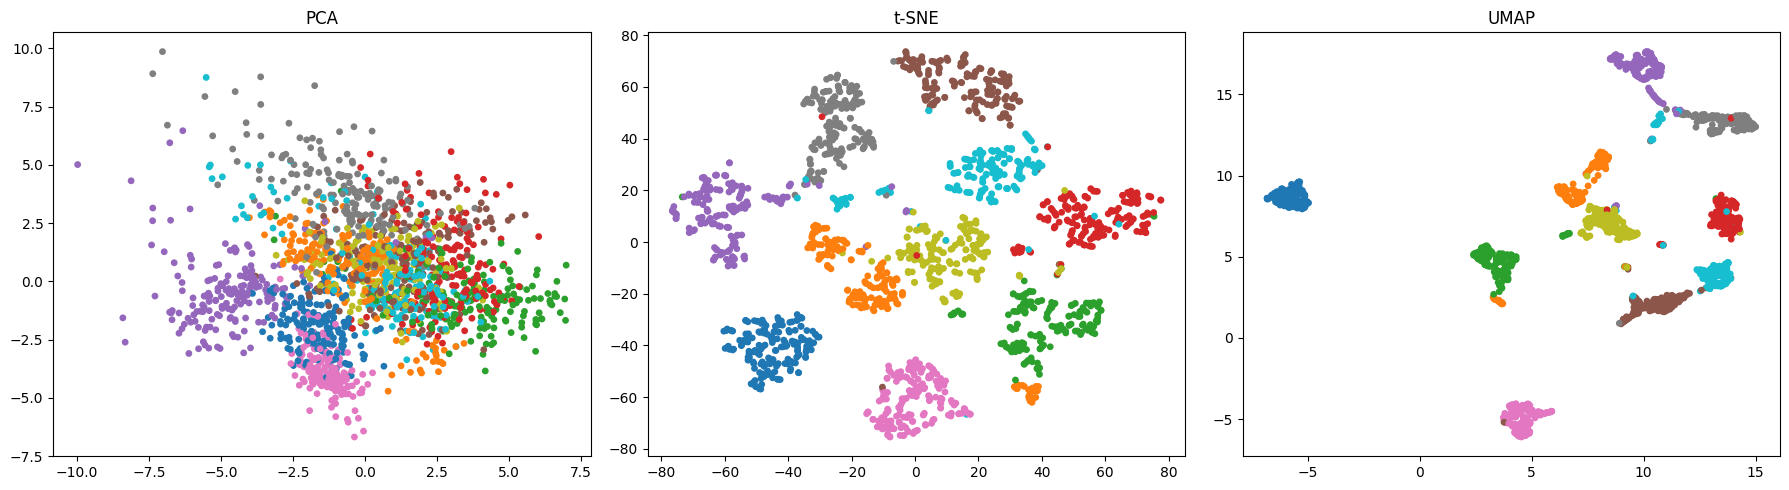

Uruchom: tensorboard --logdir=runs/digits_embedding


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from torch.utils.tensorboard import SummaryWriter


digits = load_digits()
X = digits.data
y = digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

reducers = {
    "PCA": PCA(n_components=2, random_state=42),
    "t-SNE": TSNE(
        n_components=2,
        random_state=42,
        perplexity=10,
        init="pca",
        learning_rate="auto"
    ),
    "UMAP": umap.UMAP(
        n_components=2,
        random_state=42,
        n_neighbors=10
    )
}

embeddings = {}

for name, reducer in reducers.items():
    X_reduced = reducer.fit_transform(X_scaled)

    X_reduced = np.asarray(X_reduced, dtype=np.float32)

    if X_reduced.ndim != 2 or X_reduced.shape[0] == 0:
        raise ValueError(f"{name}: błędny lub pusty embedding: {X_reduced.shape}")

    embeddings[name] = X_reduced


plt.figure(figsize=(18, 5))

for i, (name, X_reduced) in enumerate(embeddings.items(), start=1):
    plt.subplot(1, 3, i)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap="tab10", s=15)
    plt.title(name)

plt.tight_layout()
plt.show()


logdir = "runs/digits_embedding"
writer = SummaryWriter(logdir)

metadata = [str(label) for label in y]

for name, X_reduced in embeddings.items():
    writer.add_embedding(
        mat=torch.tensor(X_reduced, dtype=torch.float32),
        metadata=metadata,
        tag=name,
        global_step=0
    )

writer.flush()
writer.close()

print(f"Uruchom: tensorboard --logdir={logdir}")
print("Otwórz: http://localhost:6006/")